# Deforestation Archetypes

This notebook is a cleaned, end-to-end analysis notebook

It uses the same project root and data layout already in original notebook:

`/content/drive/MyDrive/deforestation_archetypes`

It covers:

1. loading event-level features  
2. clustering + UMAP visualization  
3. cluster summaries and galleries  
4. cluster stability analysis  
5. kNN classifier for new events  
6. proxy risk prediction model  
7. Hansen morphology clustering + risk analysis

In [1]:
# If running in Colab, mount Drive first.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Core imports
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    adjusted_rand_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import umap
import hdbscan

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 200)

In [ ]:
# -------------------------
# Paths / folders
# -------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/deforestation_archetypes")

FEATURES_PARQUET = PROJECT_ROOT / "data" / "features" / "event_features.parquet"
FEATURES_CSV_FALLBACK = PROJECT_ROOT / "data" / "features" / "event_features.csv"

HANSEN_FEATURES_CSV = PROJECT_ROOT / "data" / "events_hansen" / "event_features_hansen_sample_15000.csv"

MID_DIR = PROJECT_ROOT / "data" / "mid_presentation"
MID_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = MID_DIR / "plots"
TABLES_DIR = MID_DIR / "tables"
MODELS_DIR = MID_DIR / "models"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MID_DIR:", MID_DIR)

PROJECT_ROOT: /content/drive/MyDrive/deforestation_archetypes
MID_DIR: /content/drive/MyDrive/deforestation_archetypes/data/mid_presentation


## 1) Load event-level features

In [ ]:
# -------------------------
# Load SpaceNet / event-level features
# -------------------------
if FEATURES_PARQUET.exists():
    df = pd.read_parquet(FEATURES_PARQUET)
    feature_source = FEATURES_PARQUET
elif FEATURES_CSV_FALLBACK.exists():
    df = pd.read_csv(FEATURES_CSV_FALLBACK)
    feature_source = FEATURES_CSV_FALLBACK
else:
    raise FileNotFoundError(
        f"Could not find features at {FEATURES_PARQUET} or {FEATURES_CSV_FALLBACK}"
    )

print("Loaded features from:", feature_source)
print("Rows:", len(df), "Cols:", df.shape[1])
display(df.head())

Loaded features from: /content/drive/MyDrive/deforestation_archetypes/data/features/event_features.parquet
Rows: 1381 Cols: 542


,event_id,patch_id,split,scene_id,t0,t1,row,col,area_px,perimeter_px,compactness,eccentricity,solidity,extent,convex_area,bbox_area,aspect_ratio,n_components,edge_density,mean_r,mean_g,mean_b,std_r,std_g,std_b,masked_gray_mean,masked_gray_std,mask_frac,crop_h,crop_w,emb_000,emb_001,emb_002,emb_003,emb_004,emb_005,emb_006,emb_007,emb_008,emb_009,emb_010,emb_011,emb_012,emb_013,emb_014,emb_015,emb_016,emb_017,emb_018,emb_019,emb_020,emb_021,emb_022,emb_023,emb_024,emb_025,emb_026,emb_027,emb_028,emb_029,emb_030,emb_031,emb_032,emb_033,emb_034,emb_035,emb_036,emb_037,emb_038,emb_039,emb_040,emb_041,emb_042,emb_043,emb_044,emb_045,emb_046,emb_047,emb_048,emb_049,emb_050,emb_051,emb_052,emb_053,emb_054,emb_055,emb_056,emb_057,emb_058,emb_059,emb_060,emb_061,emb_062,emb_063,emb_064,emb_065,emb_066,emb_067,emb_068,emb_069,...,emb_412,emb_413,emb_414,emb_415,emb_416,emb_417,emb_418,emb_419,emb_420,emb_421,emb_422,emb_423,emb_424,emb_425,emb_426,emb_427,emb_428,emb_429,emb_430,emb_431,emb_432,emb_433,emb_434,emb_435,emb_436,emb_437,emb_438,emb_439,emb_440,emb_441,emb_442,emb_443,emb_444,emb_445,emb_446,emb_447,emb_448,emb_449,emb_450,emb_451,emb_452,emb_453,emb_454,emb_455,emb_456,emb_457,emb_458,emb_459,emb_460,emb_461,emb_462,emb_463,emb_464,emb_465,emb_466,emb_467,emb_468,emb_469,emb_470,emb_471,emb_472,emb_473,emb_474,emb_475,emb_476,emb_477,emb_478,emb_479,emb_480,emb_481,emb_482,emb_483,emb_484,emb_485,emb_486,emb_487,emb_488,emb_489,emb_490,emb_491,emb_492,emb_493,emb_494,emb_495,emb_496,emb_497,emb_498,emb_499,emb_500,emb_501,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
0,EV_0000000,train__L15-0331E-1257N_1327_3160_13__2018_01__...,train,L15-0331E-1257N_1327_3160_13,2018_01,2018_02,0,0,59,76.0,0.128361,0.876261,0.951613,0.893939,62,66,1.833333,5,0.238066,0.632501,0.553544,0.449752,0.205946,0.176453,0.158499,0.711408,0.127818,0.071603,38,43,0.742635,0.378440,0.958034,0.620470,0.679450,0.674782,1.739090,0.324125,0.891689,0.036019,0.108117,0.363276,0.006206,0.498615,0.395522,1.004779,0.097747,2.180119,0.214740,1.048415,0.081756,0.355573,0.362173,0.119406,1.949383,0.083236,0.858693,0.481014,0.174882,0.434689,0.624049,0.399837,0.003027,0.780731,0.168858,0.174671,0.000000,0.404891,0.346963,0.332840,0.334859,0.285133,0.022356,1.641126,0.370099,0.822631,0.217096,0.000000,0.226550,0.961156,0.076657,0.385746,0.014854,1.816712,0.028975,0.060715,0.013535,0.085370,0.245218,0.014112,0.419409,0.856377,0.437014,0.812790,0.268952,0.116308,0.000000,0.105830,0.000287,0.131703,...,0.003291,0.263799,1.473519,0.765957,0.278265,0.321292,0.558598,0.304150,0.439982,0.114409,0.066350,0.270231,4.369308,1.778314,1.589430,0.032206,0.316309,0.597447,0.197973,0.539574,0.172992,0.376201,0.005314,0.000000,0.018283,0.000000,0.237853,0.026341,0.526235,0.036054,0.102323,1.180967,0.004658,0.583762,0.146506,0.751819,0.0,0.125519,0.763081,0.205821,0.073242,0.213082,0.020825,0.295676,0.246040,0.123885,0.117314,0.250632,0.103338,0.201852,0.441714,0.135469,0.559812,2.137339,0.088177,0.192821,0.000000,0.290028,0.0,1.041326,0.550771,0.221886,0.807458,0.352065,0.010403,0.000000,0.094439,0.735622,0.417903,0.430426,0.151131,0.006380,0.453748,1.257617,0.010062,0.610208,0.123100,0.366527,0.023651,0.041798,0.411472,0.045361,0.741780,0.288740,1.054502,0.000000,0.000000,0.485396,0.115958,0.000000,0.365703,0.063775,0.008724,0.238810,0.547773,0.083921,0.175903,0.418319,0.570639,0.155045
1,EV_0000001,train__L15-0331E-1257N_1327_3160_13__2018_03__...,train,L15-0331E-1257N_1327_3160_13,2018_03,2018_04,0,0,52,70.0,0.133357,0.934739,0.928571,0.866667,56,60,2.400000,3,0.199631,0.718300,0.610553,0.484711,0.243117,0.205013,0.178839,0.708397,0.052833,0.074939,37,44,0.095936,0.000000,0.080422,0.138687,0.102834,0.645754,1.117752,0.065607,1.105790,0.000000,0.102643,0.066817,0.023739,0.221419,0.863611,0.212853,0.170824,3.221875,0.968732,0.412939,0.244396,0.048432,0.143156,0.000000,0.972838,0.031919,1.327968,0.458510,0.059746,0.044579,0.338177,0.641993,0.00672

In [ ]:
# Robust feature column selection
candidate_shape_cols = [
    "area_px", "perimeter_px", "perimeter",
    "compactness", "eccentricity", "solidity", "extent",
    "convex_area", "bbox_area", "aspect_ratio", "n_components",
    "edge_density", "mask_frac", "crop_h", "crop_w", "hull_ratio"
]

shape_cols = [c for c in candidate_shape_cols if c in df.columns]

if len(shape_cols) < 5:
    raise ValueError(f"Too few usable morphology columns found: {shape_cols}")

emb_cols = [c for c in df.columns if c.startswith("emb_")]

print("Shape columns:", shape_cols)
print("Num embedding cols:", len(emb_cols))

Shape columns: ['area_px', 'perimeter_px', 'compactness', 'eccentricity', 'solidity', 'extent', 'convex_area', 'bbox_area', 'aspect_ratio', 'n_components', 'edge_density', 'mask_frac', 'crop_h', 'crop_w']
Num embedding cols: 512


## 2) UMAP + HDBSCAN clustering

In [ ]:
def cluster_events(input_df, feature_cols, umap_neighbors=15, umap_min_dist=0.1,
                   umap_components=5, min_cluster_size=30, min_samples=5,
                   umap_random_state=42):
    tmp = input_df.copy()

    X = tmp[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values
    Xs = StandardScaler().fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=umap_neighbors,
        min_dist=umap_min_dist,
        n_components=umap_components,
        random_state=umap_random_state
    )
    Z = reducer.fit_transform(Xs)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples
    )
    labels = clusterer.fit_predict(Z)

    tmp["cluster"] = labels
    tmp["umap_1"] = Z[:, 0]
    tmp["umap_2"] = Z[:, 1]
    if Z.shape[1] > 2:
        for i in range(2, Z.shape[1]):
            tmp[f"umap_{i+1}"] = Z[:, i]

    return tmp, reducer, clusterer

clustered_df, reducer, clusterer = cluster_events(df, shape_cols)

n_clusters = len(set(clustered_df["cluster"])) - (1 if -1 in set(clustered_df["cluster"]) else 0)
noise_pct = 100 * (clustered_df["cluster"] == -1).mean()

print("Clusters:", n_clusters)
print("Noise %:", round(noise_pct, 2))
print(clustered_df["cluster"].value_counts().head(15))

clustered_out_csv = TABLES_DIR / "event_features_with_clusters.csv"
clustered_df.to_csv(clustered_out_csv, index=False)
print("Saved clustered table ->", clustered_out_csv)

Clusters: 14
Noise %: 8.62
cluster
 0     253
 9     216
 11    163
-1     119
 7     108
 1      95
 6      81
 3      64
 13     52
 4      47
 5      41
 12     41
 10     39
 2      31
 8      31
Name: count, dtype: int64
Saved clustered table -> /content/drive/MyDrive/deforestation_archetypes/data/mid_presentation/tables/event_features_with_clusters.csv


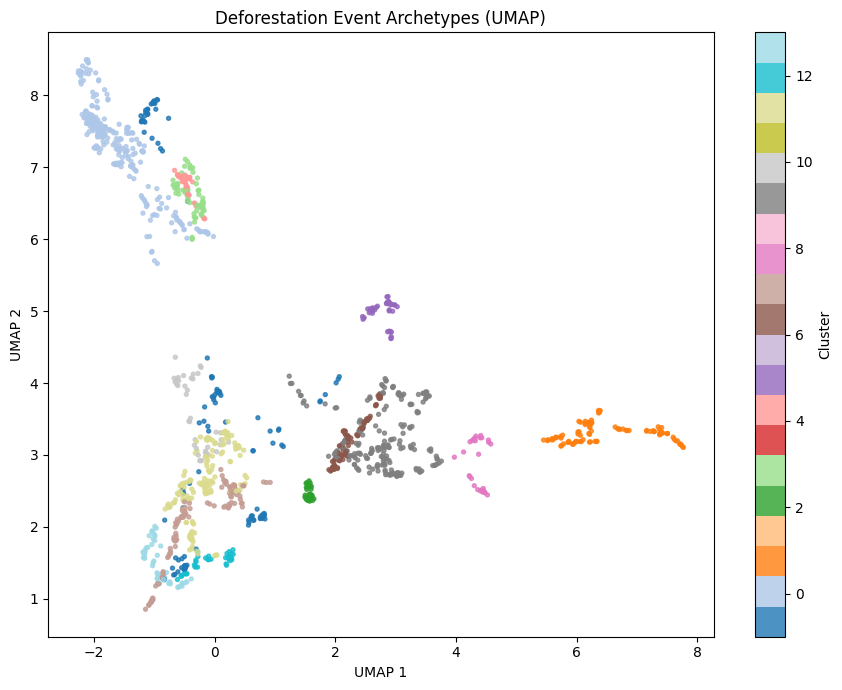

In [ ]:
# UMAP plot
plt.figure(figsize=(9, 7))
sc = plt.scatter(
    clustered_df["umap_1"],
    clustered_df["umap_2"],
    c=clustered_df["cluster"],
    s=8,
    cmap="tab20",
    alpha=0.8
)
plt.colorbar(sc, label="Cluster")
plt.title("Deforestation Event Archetypes (UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "umap_archetypes.png", dpi=180)
plt.show()

In [ ]:
# Cluster summary table
cluster_summary = (
    clustered_df[clustered_df["cluster"] != -1]
    .groupby("cluster")[shape_cols]
    .agg(["mean", "median", "std", "count"])
)

cluster_summary.to_csv(TABLES_DIR / "cluster_summary_stats.csv")
display(cluster_summary.head())
print("Saved ->", TABLES_DIR / "cluster_summary_stats.csv")

area_px                          perimeter_px              \
                mean median         std count         mean      median   
cluster                                                                  
0          73.371542   52.0   52.023235   253    89.075482   64.828427   
1        1104.715789  903.0  510.859636    95   924.558801  863.905592   
2          63.290323   71.0   13.550384    31   390.514820  411.207107   
3          52.437500   46.5   22.729517    64   126.917450  118.139087   
4          70.531915   54.0   39.923215    47    94.984016   88.621320   

                          compactness                           eccentricity  \
                std count        mean    median       std count         mean   
cluster                                                                        
0         62.833113   253    0.367470  0.160370  0.729620   253     0.879216   
1        363.408629    95    0.034218  0.014571  0.093019    95     0.789138   
2         62.827478    31    0.005306  0.005020  0.000964    31     0.538807   
3         73.705227    64    0.107199  0.046335  0.132745    64     0.702665   
4         49.444646    47    0.170840  0.110584  0.175385    47     0.935043   

                                   solidity                            \
           median       std count      mean    median       std count   
cluster                                                                 
0        0.931818  0.136783   253  0.761818  0.755556  0.117359   253   
1        0.833170  0.169215    95  0.803671  0.784959  0.103783    95   
2        0.567552  0.068156    31  0.799485  0.828571  0.055140    31   
3        0.711631  0.178318    64  0.952010  0.959855  0.049566    64   
4        0.964879  0.061223    47  0.974838  1.000000  0.040767    47   

           extent                            convex_area                      \
             mean    median       std count         mean  median         std   
cluster                                                                        
0        0.430837  0.436364  0.111727   253    99.596838    70.0   77.065703   
1        0.539459  0.536098  0.117821    95  1378.589474  1104.0  627.231819   
2        0.685340  0.708333  0.053316    31    79.129032    88.0   15.719928   
3        0.904535  0.921684  0.102939    64    55.953125    47.5   25.977053   
4        0.952911  1.000000  0.073121    47    72.297872    56.0   40.900151   

                 bbox_area                            aspect_ratio            \
        count         mean  median          std count         mean    median   
cluster                                                                        
0         253   179.367589   136.0   131.816052   253     1.233295  1.076923   
1          95  2145.200000  1640.0  1094.223660    95     1.057070  0.861111   
2          31    91.935484   100.0    16.968472    31     0.977150  1.000000   
3          64    60.546875    48.0    31.307958    64     0.807932  0.800000   
4          47    74.042553    60.0    41.802308    47     3.614361  3.499999   

                        n_components                         edge_density  \
              std count         mean median        std count         mean   
cluster                                                                     
0        0.582147   253     4.000000    3.0   3.202182   253     0.192334   
1        0.602492    95    24.768421   22.0  14.211512    95     0.169801   
2        0.122272    31    34.967742   33.0   5.683214    31     0.230973   
3        0.324845    64     9.046875    7.0   6.915429    64     0.168393   
4        1.625752    47     5.063830    4.0   3.941994    47     0.177067   

                                  mask_frac                            \
           median       std count      mean    median       std count   
cluster                                                                 
0        0.195122  0.042652   253  0.075584  0.053244  0.051996   253   
1  

Saved -> /content/drive/MyDrive/deforestation_archetypes/data/mid_presentation/tables/cluster_summary_stats.csv


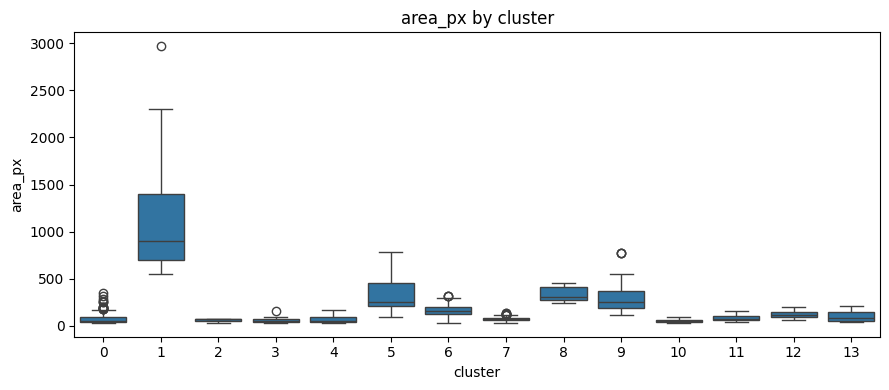

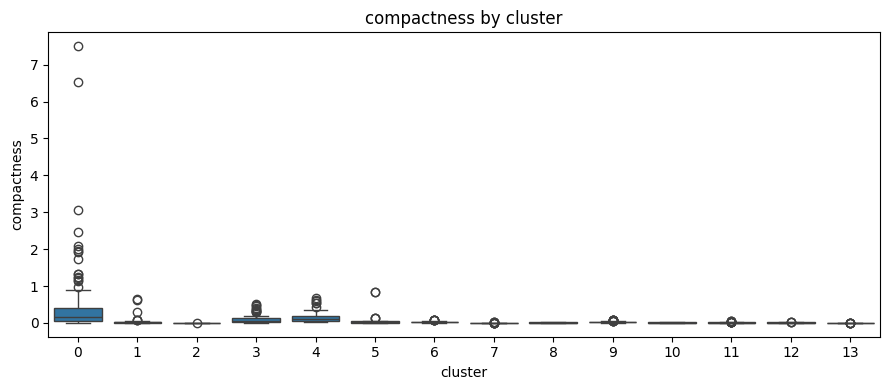

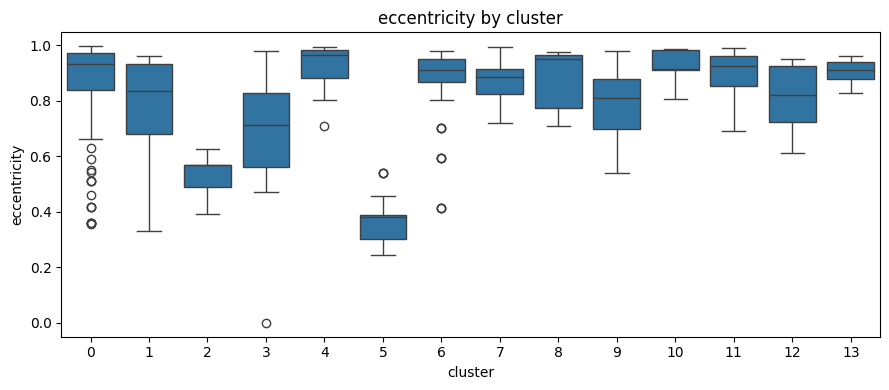

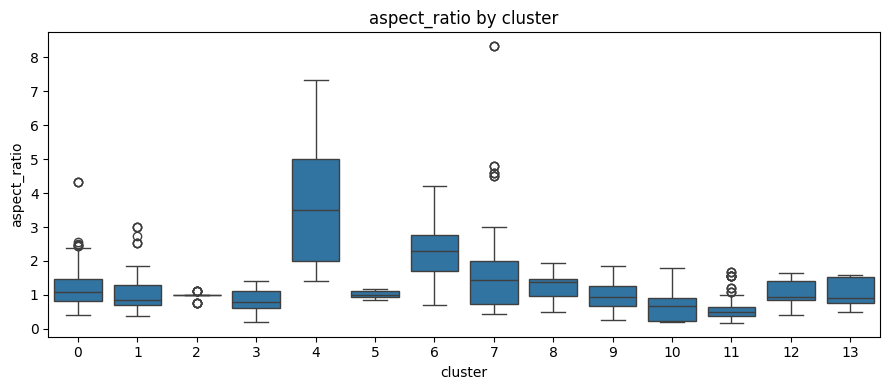

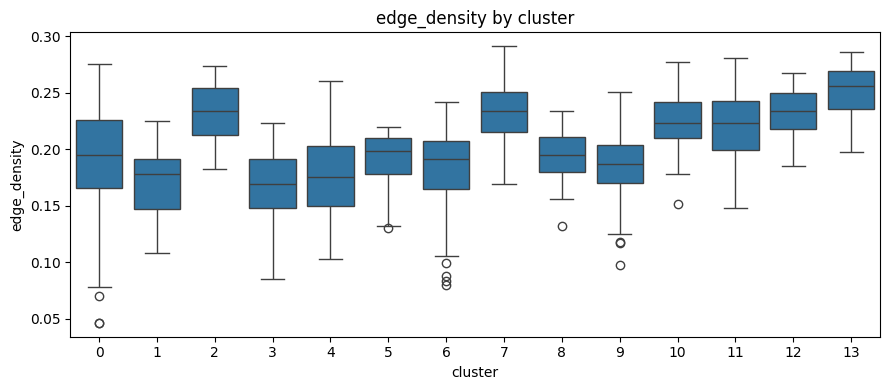

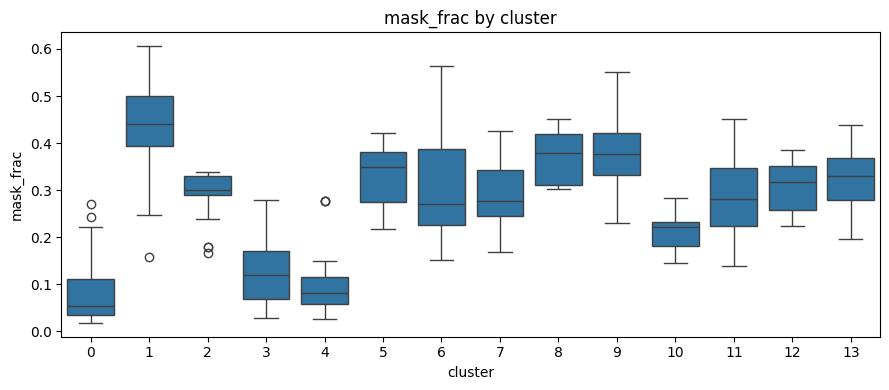

In [ ]:
# A few core boxplots for presentation
plot_cols = [c for c in ["area_px", "compactness", "eccentricity", "aspect_ratio", "edge_density", "mask_frac"] if c in clustered_df.columns]

for col in plot_cols:
    plt.figure(figsize=(9, 4))
    sns.boxplot(data=clustered_df[clustered_df["cluster"] != -1], x="cluster", y=col)
    plt.title(f"{col} by cluster")
    plt.xticks(rotation=0)
    plt.tight_layout()
    out = PLOTS_DIR / f"boxplot_{col}_by_cluster.png"
    plt.savefig(out, dpi=180)
    plt.show()

## 3) Cluster stability

This measures whether the archetypes are robust instead of being artifacts of one exact run.

We vary the UMAP random seed and add tiny noise to the morphology features, then compare cluster labels with **Adjusted Rand Index (ARI)**.

In [ ]:
def run_labels_for_stability(input_df, feature_cols, seed, noise_std=0.01):
    X = input_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(float)

    rng = np.random.default_rng(seed)
    col_scales = np.nanstd(X, axis=0)
    col_scales[col_scales == 0] = 1.0
    noisy_X = X + rng.normal(0, noise_std, size=X.shape) * col_scales

    Xs = StandardScaler().fit_transform(noisy_X)
    Z = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=5,
        random_state=seed
    ).fit_transform(Xs)

    labels = hdbscan.HDBSCAN(
        min_cluster_size=30,
        min_samples=5
    ).fit_predict(Z)
    return labels

seeds = [7, 21, 42, 84, 126]
label_runs = {seed: run_labels_for_stability(df, shape_cols, seed) for seed in seeds}

ari_rows = []
for i, s1 in enumerate(seeds):
    for s2 in seeds[i+1:]:
        ari = adjusted_rand_score(label_runs[s1], label_runs[s2])
        ari_rows.append({"run_a": s1, "run_b": s2, "ari": ari})

stability_df = pd.DataFrame(ari_rows).sort_values("ari", ascending=False)
stability_df.to_csv(TABLES_DIR / "cluster_stability_ari.csv", index=False)

print("Cluster stability (ARI across runs):")
display(stability_df)
print("Mean ARI:", round(stability_df["ari"].mean(), 4))

In [ ]:
# Heatmap for ARI matrix
ari_mat = pd.DataFrame(index=seeds, columns=seeds, dtype=float)
for s1 in seeds:
    for s2 in seeds:
        ari_mat.loc[s1, s2] = adjusted_rand_score(label_runs[s1], label_runs[s2])

plt.figure(figsize=(6, 5))
sns.heatmap(ari_mat, annot=True, fmt=".3f", cmap="viridis")
plt.title("Cluster Stability (ARI)")
plt.xlabel("Run seed")
plt.ylabel("Run seed")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cluster_stability_ari_heatmap.png", dpi=180)
plt.show()

## 4) kNN classifier for new events

Train on discovered clusters to test whether archetypes are learnable on held-out events.

In [ ]:
knn_df = clustered_df.copy()
knn_df = knn_df[knn_df["cluster"] != -1].reset_index(drop=True)

if knn_df["cluster"].nunique() < 2:
    raise ValueError("Need at least 2 non-noise clusters for kNN classification.")

knn_feature_cols = shape_cols.copy()
X = knn_df[knn_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).values
y = knn_df["cluster"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
# Confusion matrix
labels_sorted = sorted(np.unique(y_test))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=labels_sorted,
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)
plt.title("kNN Archetype Classification on Held-Out Events")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "knn_confusion_matrix.png", dpi=180)
plt.show()

# cross-val score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(knn_model, X, y, cv=cv, scoring="accuracy")
print("5-fold CV accuracy:", np.round(cv_scores, 4))
print("Mean CV accuracy:", round(cv_scores.mean(), 4))

## 5) Proxy risk prediction model

Since true longitudinal risk labels may not yet be available, define a **proxy risk score** using event size + irregularity.

This is good for the mid presentation because it lets you say:

> we move from detection -> archetype discovery -> actionable risk scoring

In [ ]:
risk_df = clustered_df.copy()

# Robust perimeter column
perim_col = "perimeter_px" if "perimeter_px" in risk_df.columns else ("perimeter" if "perimeter" in risk_df.columns else None)
if perim_col is None:
    raise ValueError("Need either perimeter_px or perimeter for the risk model.")

for c in ["area_px", "compactness", perim_col]:
    if c not in risk_df.columns:
        raise ValueError(f"Missing required column for risk model: {c}")

# Normalize ingredients
risk_df["area_norm"] = risk_df["area_px"] / max(risk_df["area_px"].max(), 1)
risk_df["perim_norm"] = risk_df[perim_col] / max(risk_df[perim_col].max(), 1)
risk_df["irregularity"] = 1.0 - risk_df["compactness"].clip(0, 1)

risk_df["risk_score"] = (
    0.50 * risk_df["area_norm"] +
    0.30 * risk_df["irregularity"] +
    0.20 * risk_df["perim_norm"]
)

# top 35% = high risk
threshold = risk_df["risk_score"].quantile(0.65)
risk_df["risk"] = (risk_df["risk_score"] >= threshold).astype(int)

print("Risk threshold:", round(float(threshold), 4))
print(risk_df["risk"].value_counts(normalize=True).rename("fraction"))

In [ ]:
# Prepare features for risk model
risk_feature_cols = shape_cols.copy()

# add cluster as feature if available
risk_model_df = risk_df[risk_df["cluster"] != -1].copy()

if risk_model_df["cluster"].nunique() >= 2:
    cluster_dummies = pd.get_dummies(risk_model_df["cluster"], prefix="cluster")
    risk_X = pd.concat(
        [risk_model_df[risk_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0), cluster_dummies],
        axis=1
    )
else:
    risk_X = risk_model_df[risk_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

risk_y = risk_model_df["risk"].values

X_train, X_test, y_train, y_test = train_test_split(
    risk_X, risk_y, test_size=0.2, random_state=42, stratify=risk_y
)

risk_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

risk_model.fit(X_train, y_train)
risk_pred = risk_model.predict(X_test)
risk_prob = risk_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, risk_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, risk_prob), 4))

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, risk_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, risk_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Risk Model ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "risk_model_roc.png", dpi=180)
plt.show()

In [ ]:
# Feature importance
coef = risk_model.named_steps["clf"].coef_[0]
importance = pd.Series(coef, index=risk_X.columns).sort_values(key=np.abs, ascending=False)

importance.to_csv(TABLES_DIR / "risk_model_feature_importance.csv", header=["coefficient"])
display(importance.head(20))

In [ ]:
# Risk by cluster
if "cluster" in risk_model_df.columns:
    cluster_risk = (
        risk_model_df.groupby("cluster")["risk"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "high_risk_fraction"})
        .sort_values("high_risk_fraction", ascending=False)
    )
    cluster_risk.to_csv(TABLES_DIR / "risk_by_cluster.csv")

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=cluster_risk.reset_index(),
        x="cluster", y="high_risk_fraction"
    )
    plt.ylim(0, 1)
    plt.title("High-Risk Fraction by Archetype")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "risk_by_cluster.png", dpi=180)
    plt.show()

    display(cluster_risk)

## 6) Hansen sample analysis

This section mirrors the same morphology-only archetype workflow on the Hansen sample you already created.

In [ ]:
if not HANSEN_FEATURES_CSV.exists():
    print("Hansen features file not found:", HANSEN_FEATURES_CSV)
else:
    hansen = pd.read_csv(HANSEN_FEATURES_CSV)
    print("Loaded Hansen features:", hansen.shape)
    display(hansen.head())

In [ ]:
if HANSEN_FEATURES_CSV.exists():
    hansen_cols = [c for c in [
        "area_px", "perimeter", "compactness", "eccentricity",
        "aspect_ratio", "solidity", "hull_ratio", "edge_density",
        "mask_frac", "crop_h", "crop_w"
    ] if c in hansen.columns]

    # Adjusted HDBSCAN parameters to reduce noise cluster size
    hansen_clustered, _, _ = cluster_events(
        hansen,
        hansen_cols,
        umap_neighbors=15,
        umap_min_dist=0.1,
        umap_components=5,
        min_cluster_size=20,  # Lowered from 30
        min_samples=3,        # Lowered from 8
        umap_random_state=42
    )

    hansen_clustered.to_csv(TABLES_DIR / "hansen_features_with_clusters.csv", index=False)
    print(hansen_clustered["cluster"].value_counts().head(15))

    plt.figure(figsize=(9, 7))
    sc = plt.scatter(
        hansen_clustered["umap_1"], hansen_clustered["umap_2"],
        c=hansen_clustered["cluster"], s=6, cmap="tab20", alpha=0.8
    )
    plt.colorbar(sc, label="Cluster")
    plt.title("Hansen Archetypes (UMAP)")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "hansen_umap.png", dpi=180)
    plt.show()

In [ ]:
if HANSEN_FEATURES_CSV.exists():
    hansen_risk = hansen_clustered.copy()
    hansen_risk["area_norm"] = hansen_risk["area_px"] / max(hansen_risk["area_px"].max(), 1)
    hansen_risk["perim_norm"] = hansen_risk["perimeter"] / max(hansen_risk["perimeter"].max(), 1)
    hansen_risk["irregularity"] = 1.0 - hansen_risk["compactness"].clip(0, 1)
    hansen_risk["risk_score"] = (
        0.50 * hansen_risk["area_norm"] +
        0.30 * hansen_risk["irregularity"] +
        0.20 * hansen_risk["perim_norm"]
    )
    hansen_risk["risk"] = (hansen_risk["risk_score"] >= hansen_risk["risk_score"].quantile(0.65)).astype(int)

    cluster_risk_hansen = (
        hansen_risk[hansen_risk["cluster"] != -1]
        .groupby("cluster")["risk"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "high_risk_fraction"})
        .sort_values("high_risk_fraction", ascending=False)
    )
    cluster_risk_hansen.to_csv(TABLES_DIR / "hansen_risk_by_cluster.csv")

    plt.figure(figsize=(8, 4))
    sns.barplot(data=cluster_risk_hansen.reset_index(), x="cluster", y="high_risk_fraction")
    plt.ylim(0, 1)
    plt.title("Hansen High-Risk Fraction by Archetype")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "hansen_risk_by_cluster.png", dpi=180)
    plt.show()

    display(cluster_risk_hansen)

## 7) Presentation checklist

After running the notebook, your main outputs will be in:

- `data/mid_presentation/plots/`
- `data/mid_presentation/tables/`

Recommended figures for the mid presentation:

1. `umap_archetypes.png`
2. `cluster_stability_ari_heatmap.png`
3. `knn_confusion_matrix.png`
4. `risk_model_roc.png`
5. `risk_by_cluster.png`
6. `hansen_umap.png`
7. `hansen_risk_by_cluster.png`

Recommended tables:

1. `cluster_summary_stats.csv`
2. `cluster_stability_ari.csv`
3. `risk_model_feature_importance.csv`
4. `risk_by_cluster.csv`
5. `hansen_risk_by_cluster.csv`